In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import sys

# Works whether Jupyter starts from repo root or notebooks/
cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "datasphere").exists() else cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATASETS_RAW = REPO_ROOT / "datasets" / "raw"
DATASETS_PROCESSED = REPO_ROOT / "datasets" / "processed"
MODELS_DIR = REPO_ROOT / "models"
for folder in (DATASETS_RAW, DATASETS_PROCESSED, MODELS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)


def numeric_only_columns(frame, candidates=None):
    """Return true numeric columns, excluding booleans."""
    cols = list(candidates) if candidates is not None else list(frame.columns)
    numeric = []
    for col in cols:
        if col not in frame.columns:
            continue
        if pd.api.types.is_bool_dtype(frame[col]):
            continue
        if pd.api.types.is_numeric_dtype(frame[col]):
            numeric.append(col)
    return numeric


def print_iqr_outliers(frame, columns):
    for col in numeric_only_columns(frame, columns):
        series = pd.to_numeric(frame[col], errors="coerce")
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = frame[(series < lower_bound) | (series > upper_bound)]
        print(f"\n{col}")
        print("Lower Bound:", lower_bound)
        print("Upper Bound:", upper_bound)
        print("Number of Outliers:", len(outliers))


def ensure_income_log_column(frame):
    """Create household_income_log from raw income; never use household_income_monthly_usd_log."""
    if "household_income_log" not in frame.columns and "household_income_monthly_usd" in frame.columns:
        frame["household_income_log"] = np.log1p(frame["household_income_monthly_usd"])
    return frame

In [ ]:
try:
    from datasphere.data.loader import load_primary_dataset
    df = load_primary_dataset()
except FileNotFoundError:
    from datasphere.data.archives import extract_dataset_archives
    extract_dataset_archives()
    csv_path = DATASETS_RAW / "child_education_risk_intelligence.csv"
    if not csv_path.exists():
        raise FileNotFoundError(
            "Dataset missing. Run: python -m pip install -e .[dev] and ensure "
            "datasets/raw/compressed_child_education_risk_intelligence.zip exists."
        )
    df = pd.read_csv(csv_path)

print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")

Loaded 200,000 rows and 47 columns


In [ ]:
df.head()

,student_id,record_generated_date,enrollment_date,academic_year,country,state_province,location_type,age,gender,grade_level,...,early_marriage_risk_flag,community_conflict_zone,seasonal_migration_family,ngo_intervention_present,literacy_program_enrolled,language_barrier_flag,report_source,case_notes,dropout_probability_score,dropout_risk_level
0,STU-0000001,2026-03-10,2023-10-10,2021-2022,Kenya,Turkana,Urban,16,Female,11,...,False,False,False,False,False,False,NGO Field Worker,Student shows strong academic performance desp...,0.2858,Low
1,STU-0000002,2019-05-26,2018-10-28,2022-2023,Ethiopia,Oromia,Rural,6,Male,1,...,False,False,False,False,False,False,Government Survey,Household relocated; enrollment continuity at ...,0.8148,Medium
2,STU-0000003,2021-04-17,2020-04-02,2024-2025,Pakistan,Balochistan,Rural,10,Male,6,...,False,False,False,False,False,False,School Record,Family relies on child's income during harvest...,0.8617,Medium
3,STU-0000004,2023-04-29,2021-06-21,2023-2024,Nigeria,Sokoto,Urban,14,Female,9,...,False,False,False,False,False,False,NGO Field Worker,NGO field worker recommends scholarship support.,0.8831,Medium
4,STU-0000005,2024-05-31,2022-12-04,2021-2022,India,Uttar Pradesh,Rural,13,Female,7,...,False,False,False,False,False,False,Community Volunteer,Teacher reports improved engagement after coun...,0.9692,High


In [ ]:
df.tail()

,student_id,record_generated_date,enrollment_date,academic_year,country,state_province,location_type,age,gender,grade_level,...,early_marriage_risk_flag,community_conflict_zone,seasonal_migration_family,ngo_intervention_present,literacy_program_enrolled,language_barrier_flag,report_source,case_notes,dropout_probability_score,dropout_risk_level
199995,STU-0199996,2021-01-01,2020-03-14,2023-2024,Nigeria,Kano,Semi-Urban,10,Male,5,...,False,False,False,False,False,False,School Record,NGO field worker recommends scholarship support.,0.3299,Low
199996,STU-0199997,2024-10-14,2023-09-20,2021-2022,Nigeria,Kaduna,Rural,9,Female,3,...,False,False,False,False,False,False,Mobile Data Collection App,Teacher reports improved engagement after coun...,0.6820,Medium
199997,STU-0199998,2024-05-20,2022-08-05,2024-2025,India,Bihar,Semi-Urban,8,Female,5,...,False,False,False,False,False,False,School Record,NGO field worker recommends scholarship support.,0.9230,High
199998,STU-0199999,2019-11-27,2019-04-07,2024-2025,Pakistan,Sindh,Urban,11,Female,7,...,True,False,False,False,False,False,Government Survey,Long commute distance cited as barrier to regu...,0.9465,High
199999,STU-0200000,2019-12-16,2019-02-25,2021-2022,India,Rajasthan,Semi-Urban,14,Male,10,...,False,False,False,False,False,False,NGO Field Worker,No major concerns reported this academic term.,0.9643,High


In [ ]:
df.shape


(200000, 47)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   student_id                     200000 non-null  str    
 1   record_generated_date          200000 non-null  str    
 2   enrollment_date                200000 non-null  str    
 3   academic_year                  200000 non-null  str    
 4   country                        200000 non-null  str    
 5   state_province                 200000 non-null  str    
 6   location_type                  200000 non-null  str    
 7   age                            200000 non-null  int64  
 8   gender                         200000 non-null  str    
 9   grade_level                    200000 non-null  int64  
 10  school_type                    200000 non-null  str    
 11  distance_to_school_km          191861 non-null  float64
 12  mode_of_transport              200000 non

In [ ]:
#missing value sum
df.isnull().sum() 

student_id                          0
record_generated_date               0
enrollment_date                     0
academic_year                       0
country                             0
state_province                      0
location_type                       0
age                                 0
gender                              0
grade_level                         0
school_type                         0
distance_to_school_km            8139
mode_of_transport                   0
household_income_monthly_usd     7140
mother_education_level           8368
father_education_level           9803
family_size                      4762
number_of_siblings                  0
is_orphan                           0
single_parent_household             0
household_has_electricity           0
household_has_internet_access    7222
owns_smartphone_or_computer         0
child_labor_involvement             0
attendance_rate_pct              6855
average_test_score_pct           8332
previous_yea

In [ ]:
df.isnull().sum()/df.shape[0]*100#percentage of missing values

student_id                       0.0000
record_generated_date            0.0000
enrollment_date                  0.0000
academic_year                    0.0000
country                          0.0000
state_province                   0.0000
location_type                    0.0000
age                              0.0000
gender                           0.0000
grade_level                      0.0000
school_type                      0.0000
distance_to_school_km            4.0695
mode_of_transport                0.0000
household_income_monthly_usd     3.5700
mother_education_level           4.1840
father_education_level           4.9015
family_size                      2.3810
number_of_siblings               0.0000
is_orphan                        0.0000
single_parent_household          0.0000
household_has_electricity        0.0000
household_has_internet_access    3.6110
owns_smartphone_or_computer      0.0000
child_labor_involvement          0.0000
attendance_rate_pct              3.4275


In [ ]:
#finding duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#identifying the garbage value
for i in df.select_dtypes(include="object").columns:
    print(df[i].value_counts())
    print("***"*10)

student_id
STU-0000001    1
STU-0000002    1
STU-0000003    1
STU-0000004    1
STU-0000005    1
              ..
STU-0199996    1
STU-0199997    1
STU-0199998    1
STU-0199999    1
STU-0200000    1
Name: count, Length: 200000, dtype: int64
******************************
record_generated_date
2021-12-08    122
2022-09-17    121
2022-11-21    120
2023-12-08    119
2023-01-13    119
             ... 
2027-04-04      1
2018-07-24      1
2027-03-19      1
2018-08-16      1
2018-08-28      1
Name: count, Length: 3173, dtype: int64
******************************
enrollment_date
2023-02-05    122
2019-09-09    120
2018-01-16    118
2020-08-02    118
2018-08-01    118
             ... 
2018-06-22     68
2018-08-25     67
2022-08-15     67
2022-01-16     66
2020-01-16     66
Name: count, Length: 2190, dtype: int64
******************************
academic_year
2023-2024    59790
2024-2025    56057
2022-2023    48376
2021-2022    35777
Name: count, dtype: int64
******************************
countr

In [ ]:
#Exploratory Data Analysis(EDA)

In [ ]:
#descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,200000.0,11.513875,3.594650,5.0000,9.0000,12.0000,15.0000,19.0000
grade_level,200000.0,6.509420,3.454762,1.0000,4.0000,7.0000,10.0000,12.0000
distance_to_school_km,191861.0,2.966594,2.771346,0.1000,0.9000,2.1500,4.2000,33.7700
household_income_monthly_usd,192860.0,112.328918,85.348761,15.0000,56.8100,88.8750,140.5700,1843.2300
family_size,195238.0,5.234770,2.208767,2.0000,4.0000,5.0000,7.0000,14.0000
number_of_siblings,200000.0,3.234845,2.208374,0.0000,2.0000,3.0000,5.0000,12.0000
attendance_rate_pct,193145.0,77.894021,11.574133,34.5000,69.6000,79.6000,86.4000,100.0000
average_test_score_pct,191668.0,73.443564,10.041184,27.0000,66.6000,73.4000,80.2000,100.0000
number_of_school_transfers,200000.0,0.403095,0.637332,0.0000,0.0000,0.0000,1.0000,6.0000
disciplinary_incidents_count,200000.0,0.599780,0.775143,0.0000,0.0000,0.0000,1.0000,6.0000


In [ ]:
df.describe(include="object")

,student_id,record_generated_date,enrollment_date,academic_year,country,state_province,location_type,gender,school_type,mode_of_transport,mother_education_level,father_education_level,household_has_internet_access,report_source,case_notes,dropout_risk_level
count,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000,191632,190197,192778,200000,192212,200000
unique,200000,3173,2190,4,8,37,3,3,4,5,5,5,2,5,10,4
top,STU-0000001,2021-12-08,2023-02-05,2023-2024,India,Uttar Pradesh,Rural,Male,Government,Walking,Primary,Primary,False,School Record,Long commute distance cited as barrier to regu...,Low
freq,1,122,122,59790,47999,8077,103935,98269,110013,71763,61372,56845,123048,60248,19446,100014


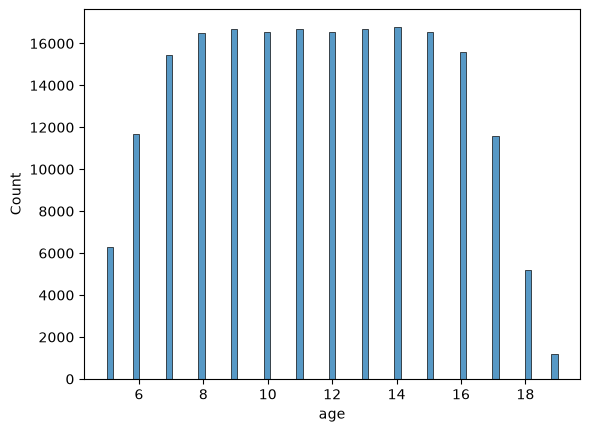

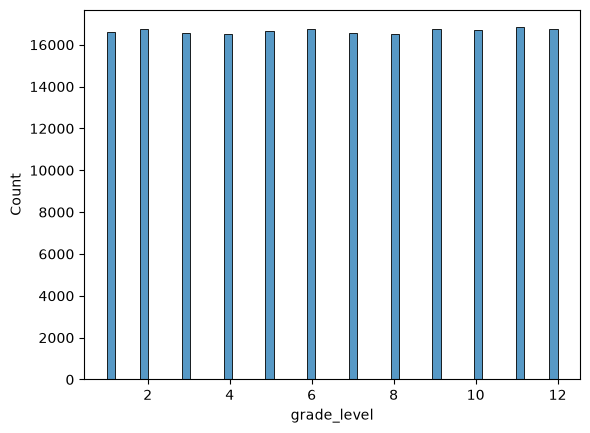

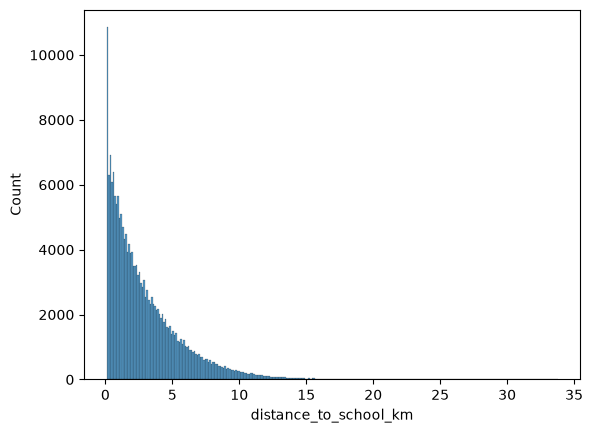

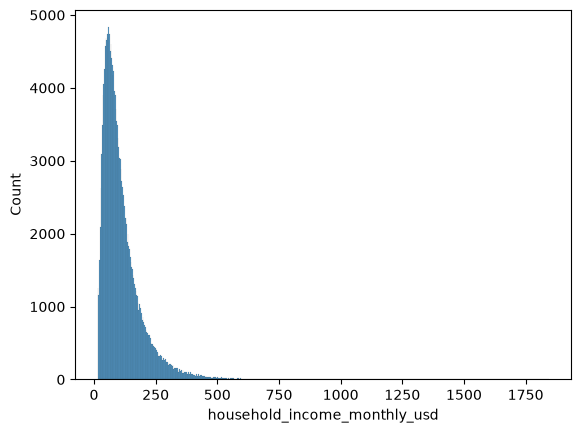

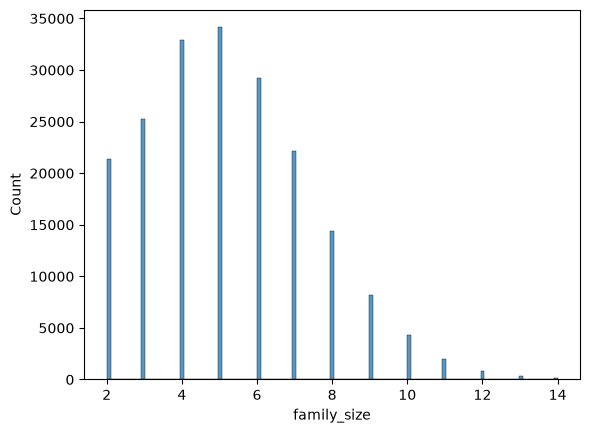

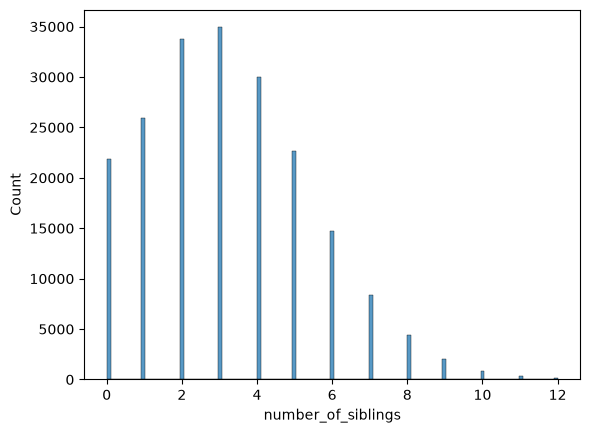

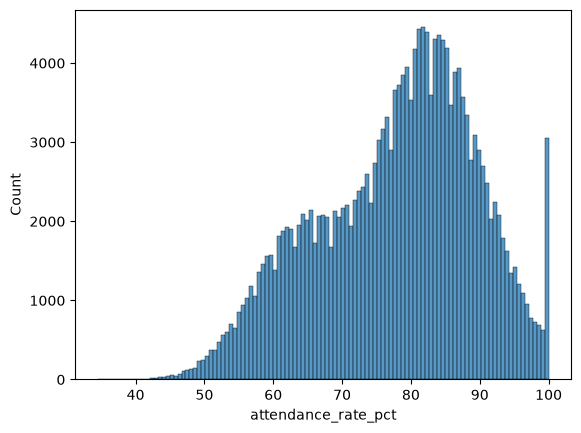

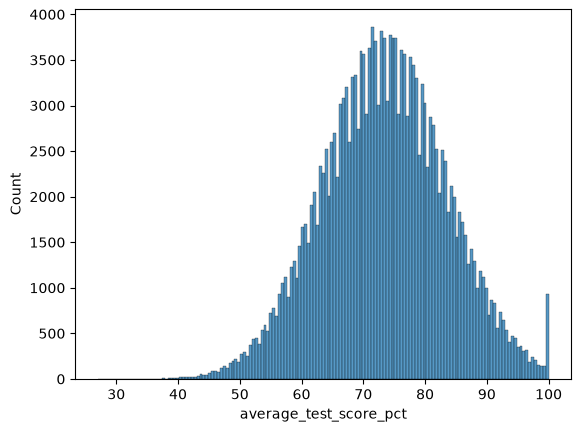

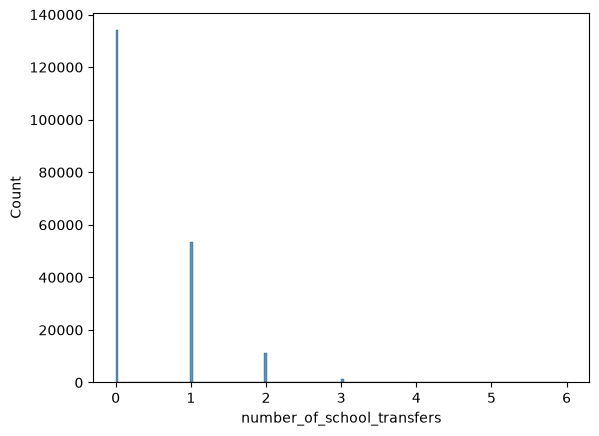

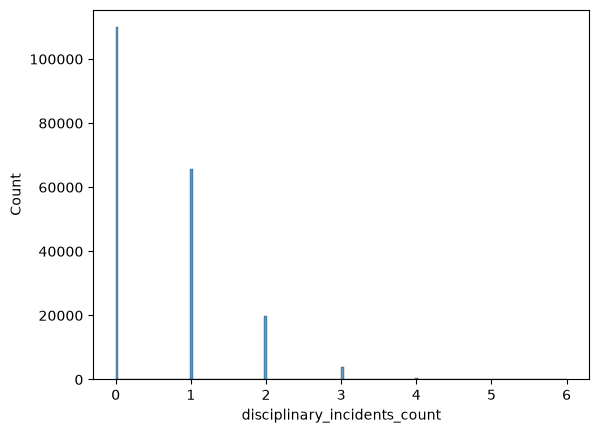

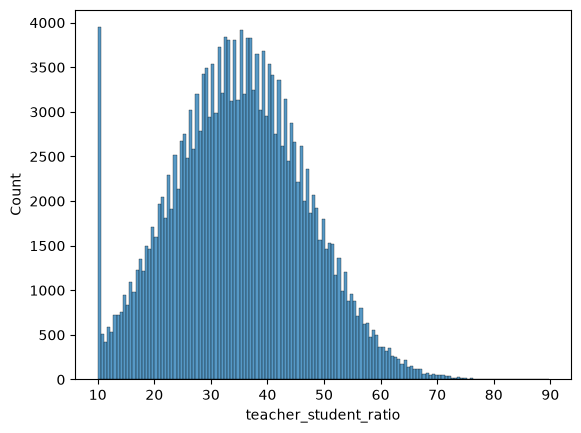

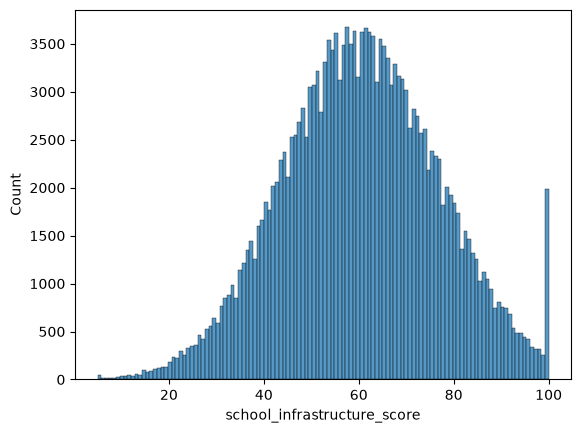

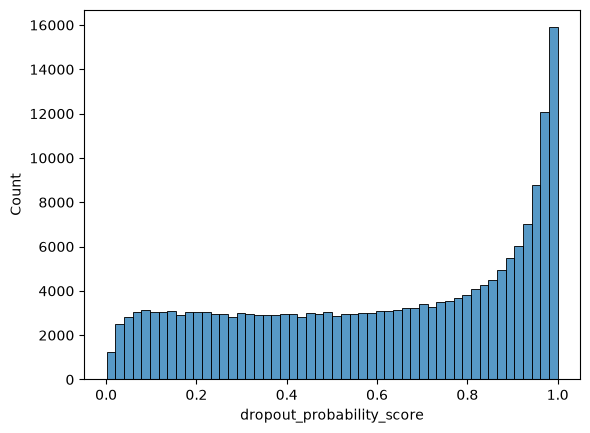

In [ ]:
#histogram to understand the distribution
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

for i in numeric_only_columns(df):
    sns.histplot(data = df, x=i)
    plt.show()
    

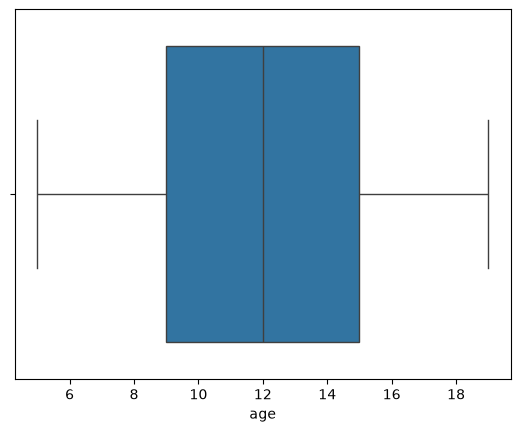

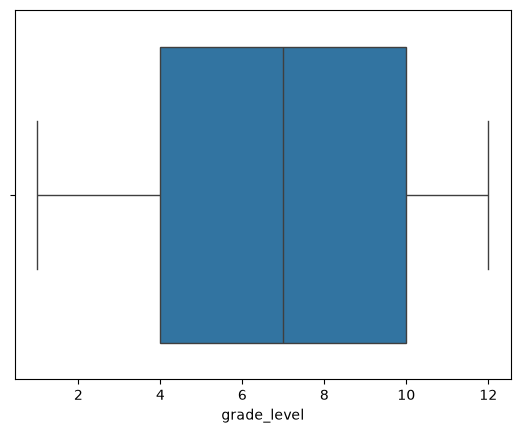

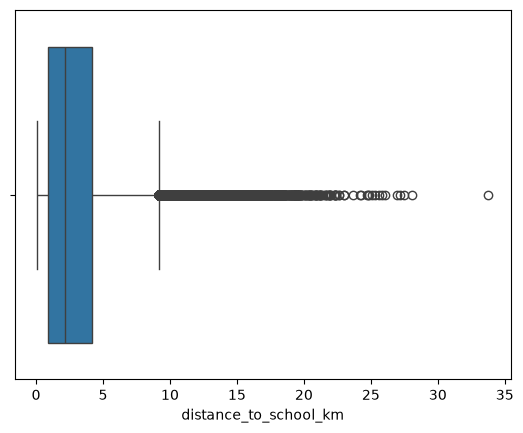

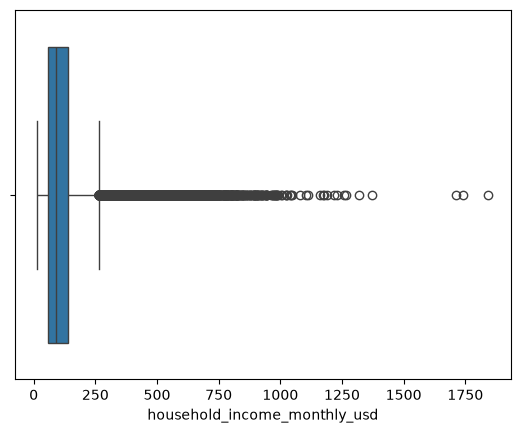

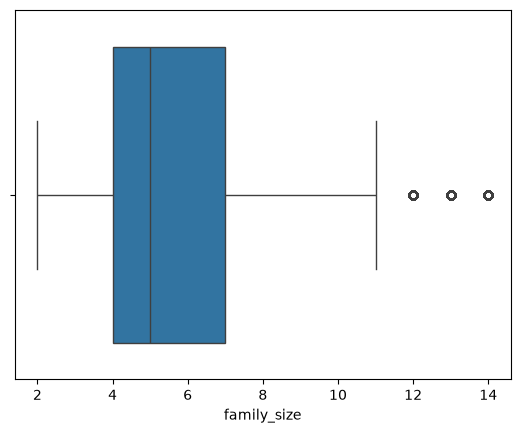

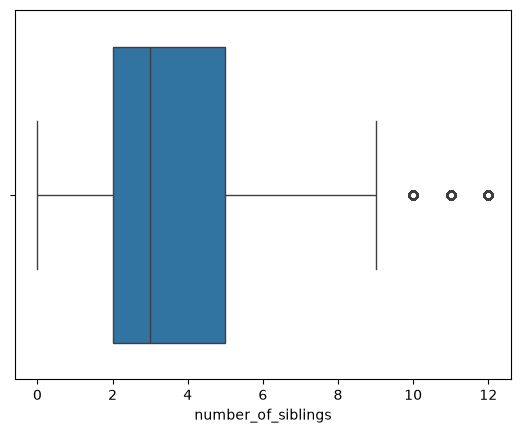

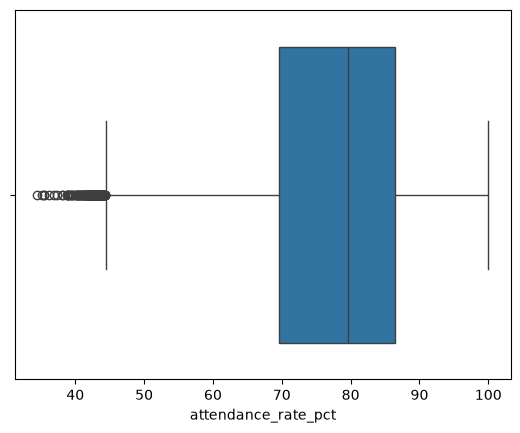

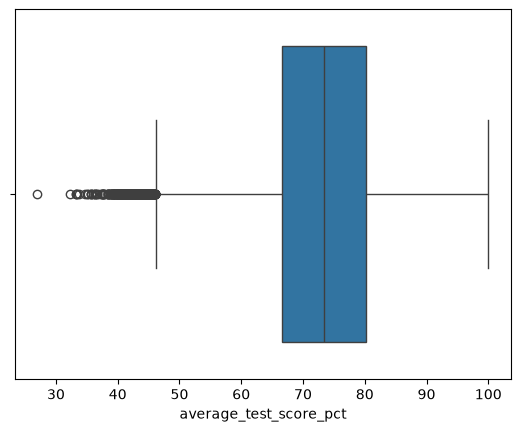

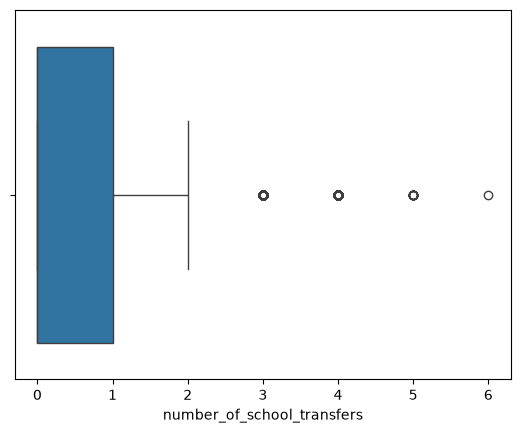

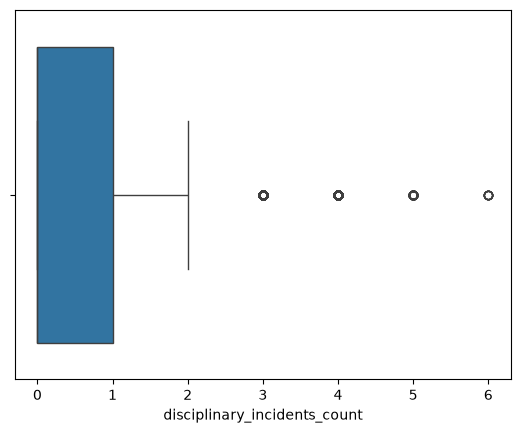

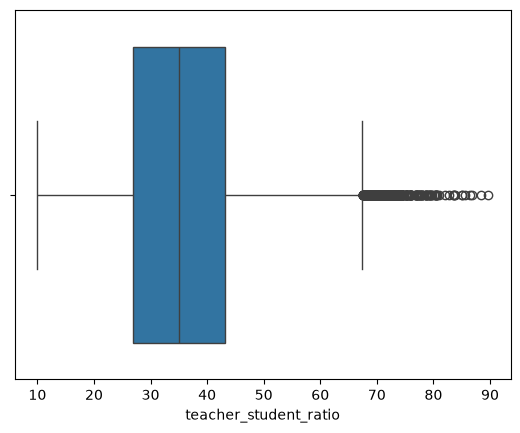

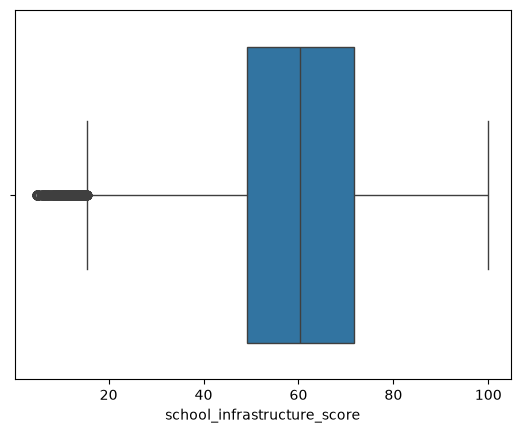

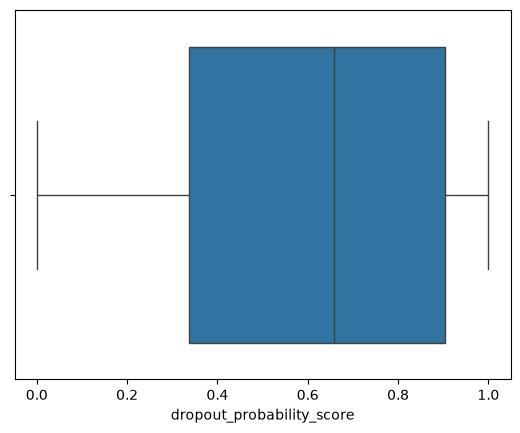

In [ ]:
#boxplot-to-identify outliers
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

for i in numeric_only_columns(df):
    sns.boxplot(data = df, x=i)
    plt.show()

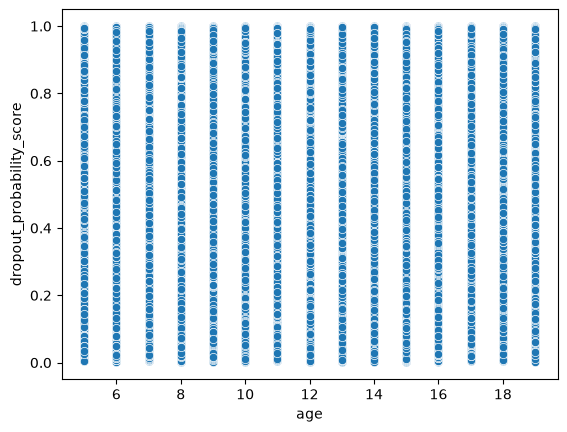

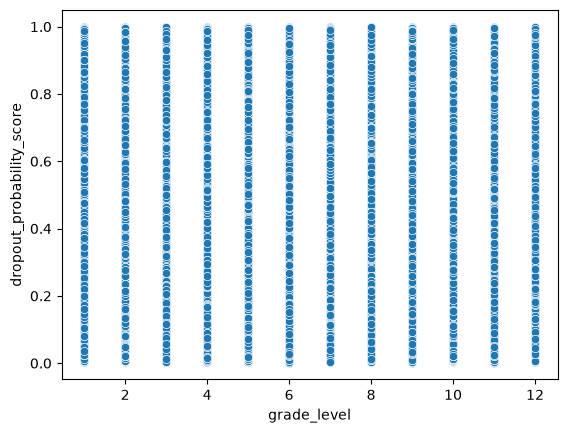

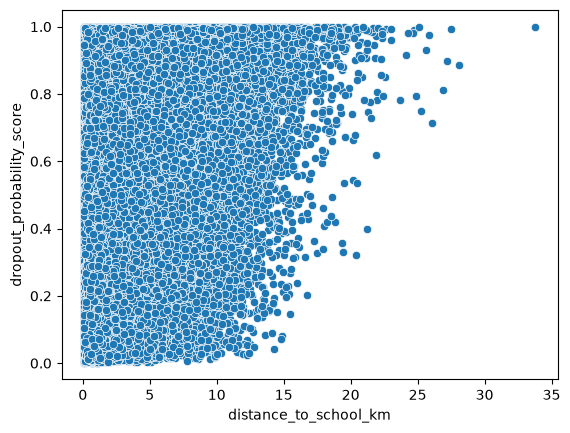

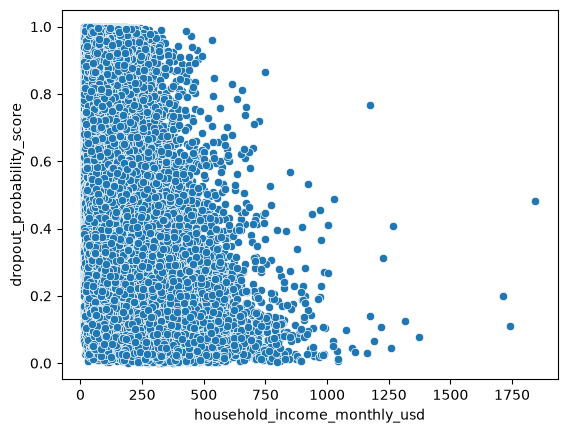

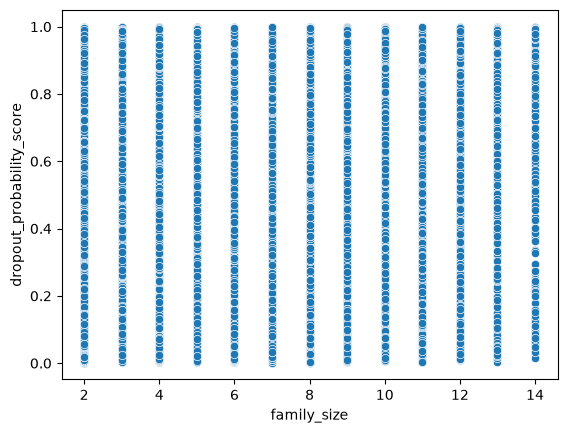

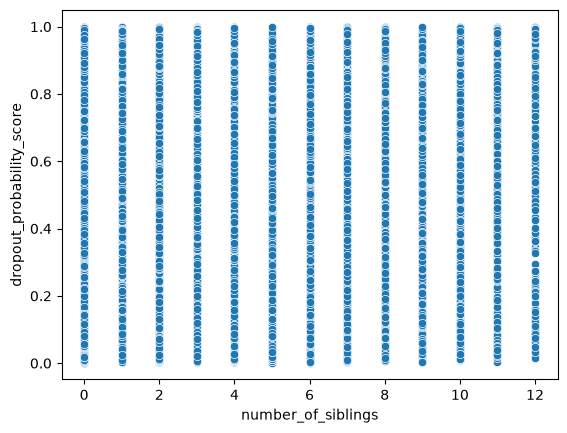

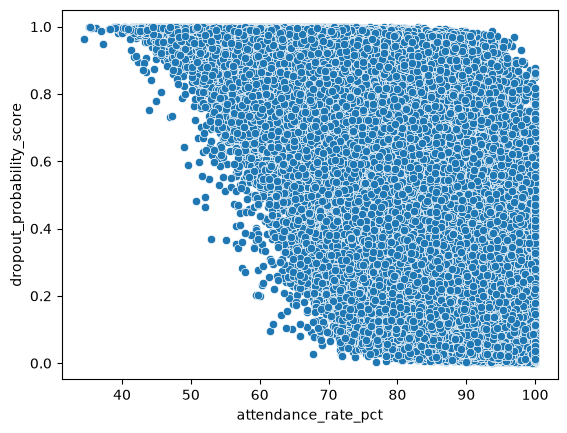

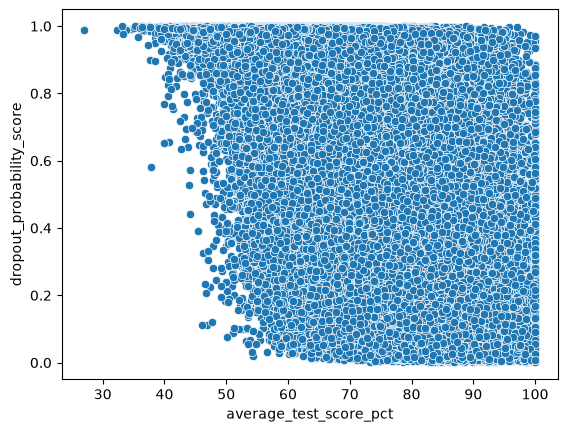

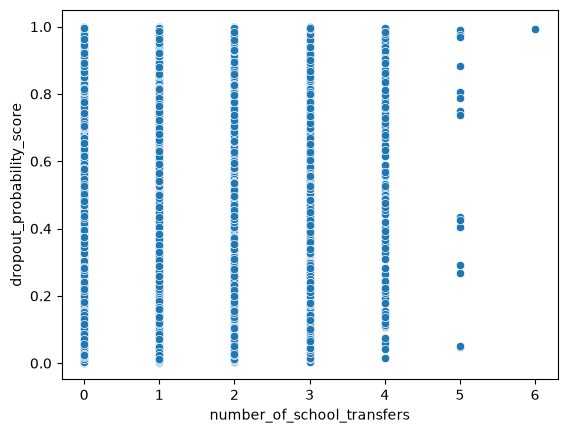

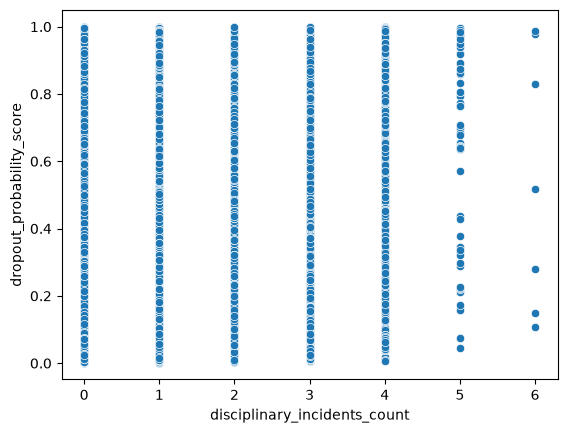

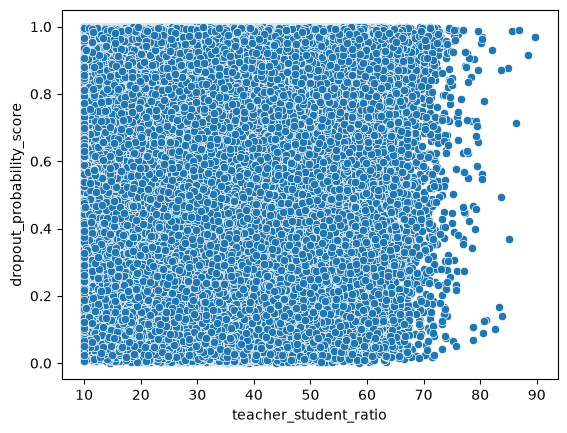

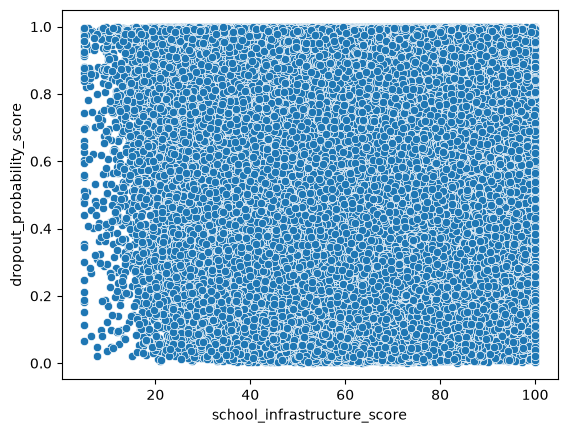

In [ ]:
#scatter plot to understand the relationship
for i in ['age', 'grade_level', 'distance_to_school_km',
       'household_income_monthly_usd', 'family_size', 'number_of_siblings',
       'attendance_rate_pct', 'average_test_score_pct',
       'number_of_school_transfers', 'disciplinary_incidents_count',
       'teacher_student_ratio', 'school_infrastructure_score']:
    sns.scatterplot(data=df, x=i, y='dropout_probability_score')
    plt.show()


In [ ]:
numeric_only_columns(df)

Index(['age', 'grade_level', 'distance_to_school_km',
       'household_income_monthly_usd', 'family_size', 'number_of_siblings',
       'attendance_rate_pct', 'average_test_score_pct',
       'number_of_school_transfers', 'disciplinary_incidents_count',
       'teacher_student_ratio', 'school_infrastructure_score',
       'dropout_probability_score'],
      dtype='str')

In [ ]:
#correlation with heatmap to interpret the relation and multicolliniarity
s = df[numeric_only_columns(df)].corr()

<Axes: >

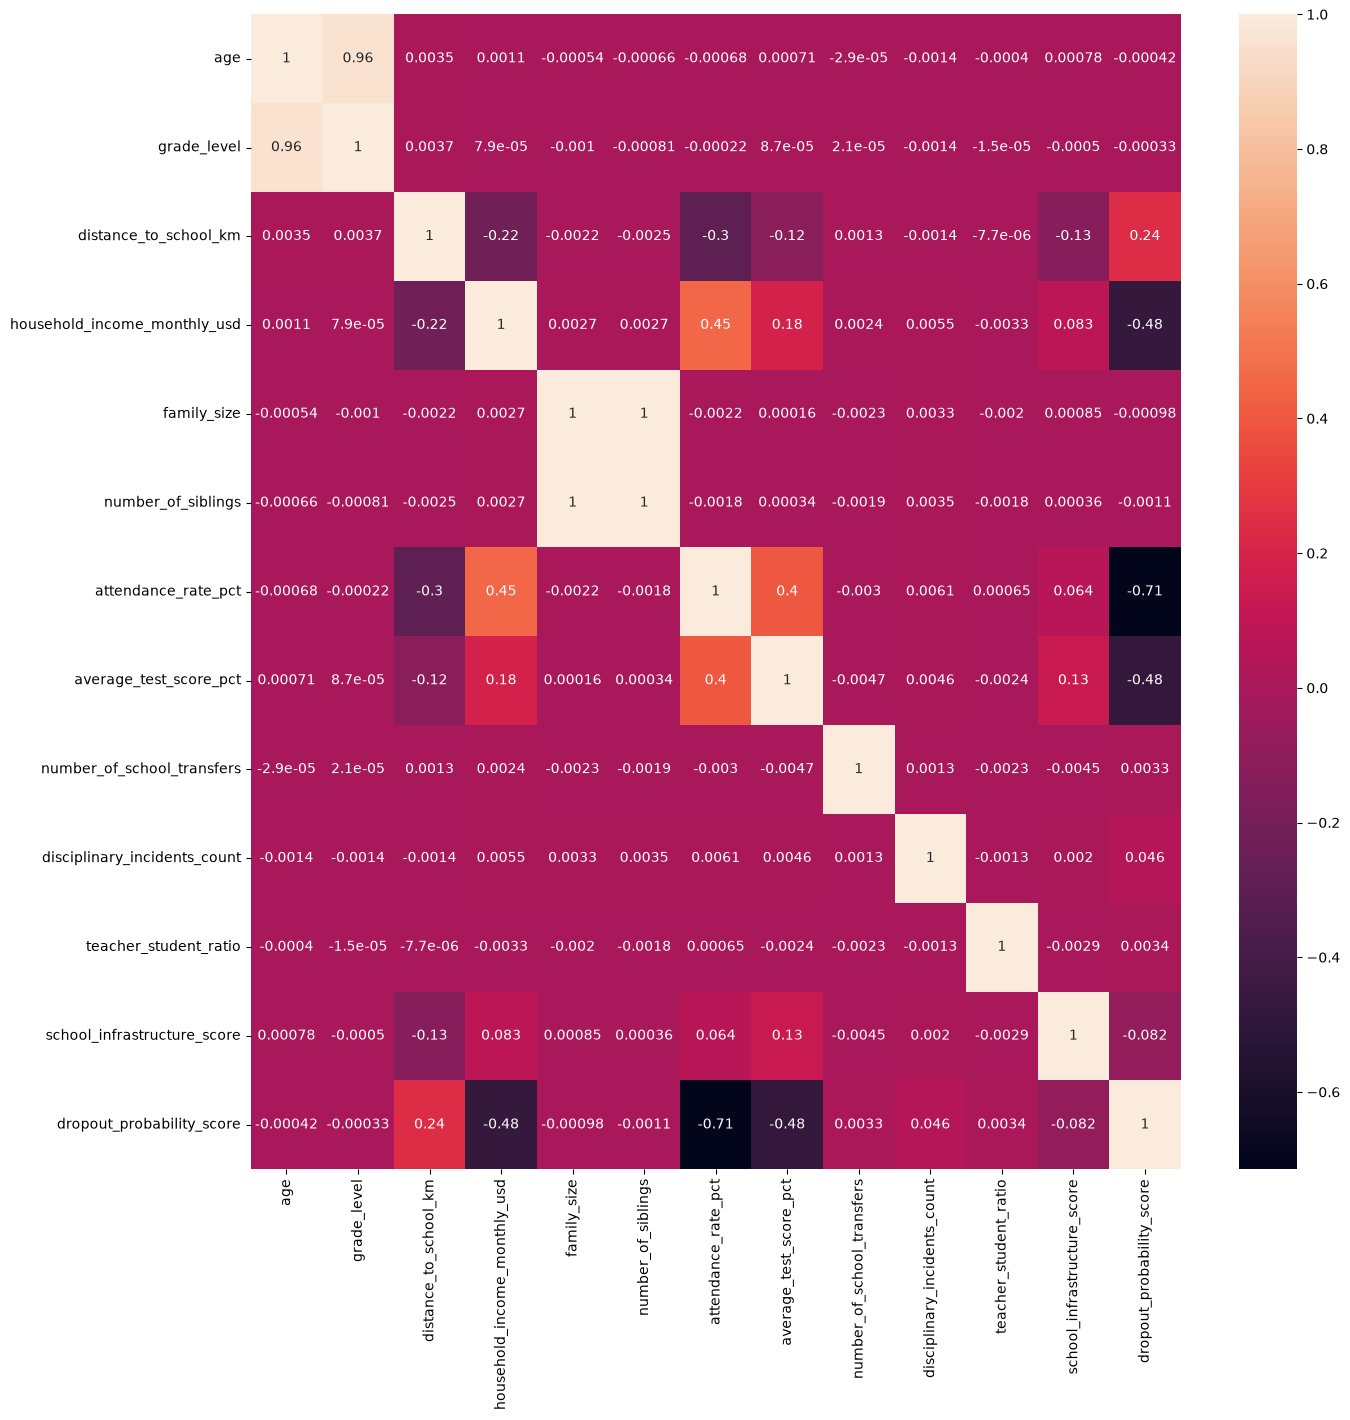

In [ ]:
plt.figure(figsize = (15,15))
sns.heatmap(s,annot=True)

In [ ]:
#miising value treatment


In [ ]:
#choose the method to input the missing value
#like mean,median, mode or KNNIputer

In [ ]:
for i in ["distance_to_school_km","household_income_monthly_usd","family_size","attendance_rate_pct",
"average_test_score_pct","teacher_student_ratio","school_infrastructure_score"]:
    df[i].fillna(df[i].median(),inplace=True)

In [ ]:
df.isnull().sum()

student_id                          0
record_generated_date               0
enrollment_date                     0
academic_year                       0
country                             0
state_province                      0
location_type                       0
age                                 0
gender                              0
grade_level                         0
school_type                         0
distance_to_school_km            8139
mode_of_transport                   0
household_income_monthly_usd     7140
mother_education_level           8368
father_education_level           9803
family_size                      4762
number_of_siblings                  0
is_orphan                           0
single_parent_household             0
household_has_electricity           0
household_has_internet_access    7222
owns_smartphone_or_computer         0
child_labor_involvement             0
attendance_rate_pct              6855
average_test_score_pct           8332
previous_yea

In [ ]:
df_clean = df.copy()


In [ ]:
numerical_cols = [
    'distance_to_school_km',
    'household_income_monthly_usd',
    'family_size',
    'attendance_rate_pct',
    'average_test_score_pct',
    'teacher_student_ratio',
    'school_infrastructure_score'
]

In [ ]:
df_clean[numerical_cols].median()

distance_to_school_km            2.150
household_income_monthly_usd    88.875
family_size                      5.000
attendance_rate_pct             79.600
average_test_score_pct          73.400
teacher_student_ratio           35.000
school_infrastructure_score     60.400
dtype: float64

In [ ]:
for col in numeric_only_columns(df_clean, numerical_cols):
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [ ]:
df_clean[numerical_cols].isnull().sum()


distance_to_school_km           0
household_income_monthly_usd    0
family_size                     0
attendance_rate_pct             0
average_test_score_pct          0
teacher_student_ratio           0
school_infrastructure_score     0
dtype: int64

In [ ]:
categorical_cols = [
    'mother_education_level',
    'father_education_level',
    'household_has_internet_access'
]

In [ ]:
df_clean['mother_education_level'].mode()[0]

'Primary'

In [ ]:
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [ ]:
df_clean['mother_education_level'] = (
    df_clean['mother_education_level'].fillna('Unknown')
)

df_clean['father_education_level'] = (
    df_clean['father_education_level'].fillna('Unknown')
)

In [ ]:
df_clean['household_has_internet_access'] = (
    df_clean['household_has_internet_access'].fillna('Unknown')
)

In [ ]:
df_clean['case_notes'] = df_clean['case_notes'].fillna('No notes')

In [ ]:
df_clean = df_clean.drop(columns=['case_notes'])

In [ ]:
df_clean.isnull().sum()

student_id                       0
record_generated_date            0
enrollment_date                  0
academic_year                    0
country                          0
state_province                   0
location_type                    0
age                              0
gender                           0
grade_level                      0
school_type                      0
distance_to_school_km            0
mode_of_transport                0
household_income_monthly_usd     0
mother_education_level           0
father_education_level           0
family_size                      0
number_of_siblings               0
is_orphan                        0
single_parent_household          0
household_has_electricity        0
household_has_internet_access    0
owns_smartphone_or_computer      0
child_labor_involvement          0
attendance_rate_pct              0
average_test_score_pct           0
previous_year_pass               0
number_of_school_transfers       0
disciplinary_inciden

In [ ]:
df_clean['attendance_rate_pct'] = (
    df_clean['attendance_rate_pct']
    .fillna(df_clean['attendance_rate_pct'].median())
)

In [ ]:
df['attendance_rate_pct'].describe()

count    193145.000000
mean         77.894021
std          11.574133
min          34.500000
25%          69.600000
50%          79.600000
75%          86.400000
max         100.000000
Name: attendance_rate_pct, dtype: float64

In [ ]:
df_clean['attendance_rate_pct'].describe()

count    200000.000000
mean         77.952494
std          11.378285
min          34.500000
25%          70.100000
50%          79.600000
75%          86.100000
max         100.000000
Name: attendance_rate_pct, dtype: float64

In [ ]:
from pathlib import Path

cleaned_path = Path("../datasets/processed/child_education_risk_intelligence_cleaned.csv")
cleaned_path.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(cleaned_path, index=False)
print(f"Cleaned dataset saved to {cleaned_path.resolve()}")


Cleaned dataset saved to C:\Users\Admin\Datasphere\datasets\processed\child_education_risk_intelligence_cleaned.csv


In [ ]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
df['attendance_rate_pct'].skew()

np.float64(-0.37625724301992086)

<Axes: ylabel='Frequency'>

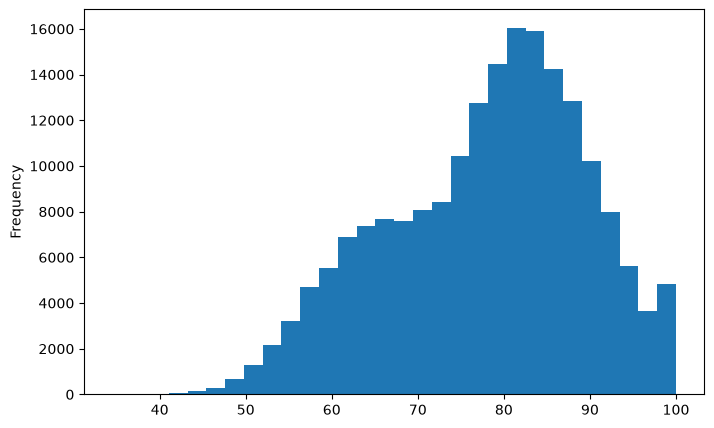

In [ ]:
df['attendance_rate_pct'].plot(
    kind='hist',
    bins=30,
    figsize=(8, 5)
)

In [ ]:
print("Mean:", df['attendance_rate_pct'].mean())
print("Median:", df['attendance_rate_pct'].median())
print("Skewness:", df['attendance_rate_pct'].skew())

Mean: 77.89402107225142
Median: 79.6
Skewness: -0.37625724301992086


In [ ]:
df['attendance_rate_pct'] = df['attendance_rate_pct'].fillna(
    df['attendance_rate_pct'].median()
)

In [ ]:
df_clean.isnull().sum()

student_id                       0
record_generated_date            0
enrollment_date                  0
academic_year                    0
country                          0
state_province                   0
location_type                    0
age                              0
gender                           0
grade_level                      0
school_type                      0
distance_to_school_km            0
mode_of_transport                0
household_income_monthly_usd     0
mother_education_level           0
father_education_level           0
family_size                      0
number_of_siblings               0
is_orphan                        0
single_parent_household          0
household_has_electricity        0
household_has_internet_access    0
owns_smartphone_or_computer      0
child_labor_involvement          0
attendance_rate_pct              0
average_test_score_pct           0
previous_year_pass               0
number_of_school_transfers       0
disciplinary_inciden

In [ ]:
#outliers treatment

In [ ]:
numerical_cols = [
    "age",
    "grade_level",
    "distance_to_school_km",
    "household_income_monthly_usd",
    "family_size",
    "number_of_siblings",
    "attendance_rate_pct",
    "average_test_score_pct",
    "number_of_school_transfers",
    "disciplinary_incidents_count",
    "bullying_incidents_reported",
    "health_issues_reported",
    "teacher_student_ratio",
    "school_infrastructure_score",
    "dropout_probability_score"
]

In [ ]:
print_iqr_outliers(df, numerical_cols)


age
Lower Bound: 0.0
Upper Bound: 24.0
Number of Outliers: 0

grade_level
Lower Bound: -5.0
Upper Bound: 19.0
Number of Outliers: 0

distance_to_school_km
Lower Bound: -4.05
Upper Bound: 9.15
Number of Outliers: 7541

household_income_monthly_usd
Lower Bound: -68.82999999999998
Upper Bound: 266.21
Number of Outliers: 10404

family_size
Lower Bound: -0.5
Upper Bound: 11.5
Number of Outliers: 1397

number_of_siblings
Lower Bound: -2.5
Upper Bound: 9.5
Number of Outliers: 1424

attendance_rate_pct
Lower Bound: 46.099999999999994
Upper Bound: 110.1
Number of Outliers: 311

average_test_score_pct
Lower Bound: 46.19999999999998
Upper Bound: 100.60000000000002
Number of Outliers: 553

number_of_school_transfers
Lower Bound: -1.5
Upper Bound: 2.5
Number of Outliers: 1638

disciplinary_incidents_count
Lower Bound: -1.5
Upper Bound: 2.5
Number of Outliers: 4691


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

In [ ]:
numerical_cols = numeric_only_columns(df)
print(numerical_cols)

In [ ]:
continuous_cols = [
    "distance_to_school_km",
    "household_income_monthly_usd",
    "attendance_rate_pct",
    "average_test_score_pct",
    "teacher_student_ratio",
    "school_infrastructure_score"
]

In [ ]:
print_iqr_outliers(df, continuous_cols)

In [ ]:
print(numerical_cols)

In [ ]:
outlier_summary = []
for col in numeric_only_columns(df, numerical_cols):
    series = pd.to_numeric(df[col], errors="coerce")
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(series < lower_bound) | (series > upper_bound)]
    outlier_summary.append({"column": col, "outliers": len(outliers)})
outlier_df = pd.DataFrame(outlier_summary)
outlier_df

In [ ]:
col = "distance_to_school_km"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df[
    (df[col] < lower_bound) |
    (df[col] > upper_bound)
][[col]].sort_values(by=col)

In [ ]:
col = "distance_to_school_km"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df[
    (df[col] < lower_bound) |
    (df[col] > upper_bound)
][[col]].sort_values(by=col)

In [ ]:
import matplotlib.pyplot as plt

for col in numeric_only_columns(df, numerical_cols):

    plt.figure(figsize=(8, 4))

    plt.boxplot(df[col].dropna())

    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)

    plt.show()

In [ ]:
continuous_cols = [
    "distance_to_school_km",
    "household_income_monthly_usd",
    "attendance_rate_pct",
    "average_test_score_pct",
    "teacher_student_ratio",
    "school_infrastructure_score"
]

In [ ]:
count_cols = [
    "number_of_siblings",
    "number_of_school_transfers",
    "disciplinary_incidents_count",
    "bullying_incidents_reported",
    "health_issues_reported"
]

In [ ]:
discrete_cols = [
    "age",
    "grade_level"
]

In [ ]:
df[
    ~df["attendance_rate_pct"].between(0, 100)
]

In [ ]:
df[
    ~df["average_test_score_pct"].between(0, 100)
]

In [ ]:
print(
    "Invalid attendance:",
    (~df["attendance_rate_pct"].between(0, 100)).sum()
)

print(
    "Invalid test score:",
    (~df["average_test_score_pct"].between(0, 100)).sum()
)

print(
    "Invalid infrastructure score:",
    (~df["school_infrastructure_score"].between(0, 100)).sum()
)

print(
    "Invalid dropout probability:",
    (~df["dropout_probability_score"].between(0, 1)).sum()
)

print(
    "Invalid age:",
    (~df["age"].between(5, 19)).sum()
)

print(
    "Invalid grade:",
    (~df["grade_level"].between(1, 12)).sum()
)

In [ ]:
df[
    ~df["average_test_score_pct"].between(0, 100)
]


In [ ]:
~df["average_test_score_pct"].between(0, 100)

In [ ]:
print("Missing test scores:",
      df["average_test_score_pct"].isna().sum())

print("Missing infrastructure:",
      df["school_infrastructure_score"].isna().sum())

In [ ]:
invalid_test_score = df[
    df["average_test_score_pct"].notna() &
    ~df["average_test_score_pct"].between(0, 100)
]

print("Invalid test scores:", len(invalid_test_score))

In [ ]:
invalid_infrastructure = df[
    df["school_infrastructure_score"].notna() &
    ~df["school_infrastructure_score"].between(0, 100)
]

print("Invalid infrastructure scores:",
      len(invalid_infrastructure))

In [ ]:
print(
    "Invalid attendance:",
    (
        df["attendance_rate_pct"].notna() &
        ~df["attendance_rate_pct"].between(0, 100)
    ).sum()
)

print(
    "Invalid test score:",
    (
        df["average_test_score_pct"].notna() &
        ~df["average_test_score_pct"].between(0, 100)
    ).sum()
)

print(
    "Invalid infrastructure score:",
    (
        df["school_infrastructure_score"].notna() &
        ~df["school_infrastructure_score"].between(0, 100)
    ).sum()
)

print(
    "Invalid dropout probability:",
    (
        df["dropout_probability_score"].notna() &
        ~df["dropout_probability_score"].between(0, 1)
    ).sum()
)

print(
    "Invalid age:",
    (
        df["age"].notna() &
        ~df["age"].between(5, 19)
    ).sum()
)

print(
    "Invalid grade:",
    (
        df["grade_level"].notna() &
        ~df["grade_level"].between(1, 12)
    ).sum()
)

In [ ]:
for i in [
    "distance_to_school_km",
    "household_income_monthly_usd",
    "family_size",
    "attendance_rate_pct",
    "average_test_score_pct",
    "teacher_student_ratio",
    "school_infrastructure_score"
]:
    df[i] = df[i].fillna(df[i].median())

In [ ]:
df["average_test_score_pct"].isna().sum()

In [ ]:
df["school_infrastructure_score"].isna().sum()

In [ ]:
print(df["average_test_score_pct"].isna().sum())
print(df["school_infrastructure_score"].isna().sum())

In [ ]:
for col in [
    "distance_to_school_km",
    "household_income_monthly_usd",
    "family_size",
    "attendance_rate_pct",
    "average_test_score_pct",
    "teacher_student_ratio",
    "school_infrastructure_score"
]:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
print(df["average_test_score_pct"].isna().sum())
print(df["school_infrastructure_score"].isna().sum())

In [ ]:
print(df["average_test_score_pct"].describe())
print(df["school_infrastructure_score"].describe())

In [ ]:
print(
    df[
        ~df["average_test_score_pct"].between(0, 100)
    ]["average_test_score_pct"]
)

In [ ]:
print(
    df[
        ~df["school_infrastructure_score"].between(0, 100)
    ]["school_infrastructure_score"]
)

In [ ]:
~df["average_test_score_pct"].between(0, 100)

In [ ]:
df["average_test_score_pct"] = df["average_test_score_pct"].fillna(
    df["average_test_score_pct"].median()
)

In [ ]:
df["average_test_score_pct"].isnull().sum()

In [ ]:
(~df["average_test_score_pct"].between(0, 100)).sum()

In [ ]:
(~df["school_infrastructure_score"].between(0, 100)).sum()

In [ ]:
(~df["attendance_rate_pct"].between(0, 100)).sum()

In [ ]:
~df["average_test_score_pct"].between(0, 100)

In [ ]:
continuous_cols = [
    "distance_to_school_km",
    "household_income_monthly_usd",
    "attendance_rate_pct",
    "average_test_score_pct",
    "teacher_student_ratio",
    "school_infrastructure_score"
]

In [ ]:
print_iqr_outliers(df, continuous_cols)

In [ ]:
Q1 = df["average_test_score_pct"].quantile(0.25)
Q3 = df["average_test_score_pct"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

In [ ]:
Q1 = df["school_infrastructure_score"].quantile(0.25)
Q3 = df["school_infrastructure_score"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

In [ ]:
for col in [
    "average_test_score_pct",
    "school_infrastructure_score"
]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print("\n", col)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Outlier count:", len(outliers))
    print("Outlier percentage:",
          len(outliers) / len(df) * 100)

In [ ]:
col = "average_test_score_pct"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[
    (df[col] < lower) |
    (df[col] > upper)
][col].value_counts().sort_index()

In [ ]:
col = "school_infrastructure_score"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[
    (df[col] < lower) |
    (df[col] > upper)
][col].value_counts().sort_index()

In [ ]:
Q1 = df["average_test_score_pct"].quantile(0.25)
Q3 = df["average_test_score_pct"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

In [ ]:
outliers = df[
    (df["average_test_score_pct"] < lower_bound) |
    (df["average_test_score_pct"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

In [ ]:
print(
    outliers["average_test_score_pct"]
    .value_counts()
    .sort_index()
)

In [ ]:
lower_outliers = df[
    df["average_test_score_pct"] < lower_bound
]

upper_outliers = df[
    df["average_test_score_pct"] > upper_bound
]

print("Lower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

print("\nLower-side values:")
print(
    lower_outliers["average_test_score_pct"]
    .value_counts()
    .sort_index()
)

print("\nUpper-side values:")
print(
    upper_outliers["average_test_score_pct"]
    .value_counts()
    .sort_index()
)

In [ ]:
Q1 = df["school_infrastructure_score"].quantile(0.25)
Q3 = df["school_infrastructure_score"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

lower_outliers = df[
    df["school_infrastructure_score"] < lower_bound
]

upper_outliers = df[
    df["school_infrastructure_score"] > upper_bound
]

print("\nLower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print("\nLower-side values:")
print(
    lower_outliers["school_infrastructure_score"]
    .value_counts()
    .sort_index()
)

print("\nUpper-side values:")
print(
    upper_outliers["school_infrastructure_score"]
    .value_counts()
    .sort_index()
)

In [ ]:
Q1 = df["distance_to_school_km"].quantile(0.25)
Q3 = df["distance_to_school_km"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

lower_outliers = df[
    df["distance_to_school_km"] < lower_bound
]

upper_outliers = df[
    df["distance_to_school_km"] > upper_bound
]

print("\nLower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print("\nLower-side values:")
print(
    lower_outliers["distance_to_school_km"]
    .value_counts()
    .sort_index()
)

print("\nUpper-side values:")
print(
    upper_outliers["distance_to_school_km"]
    .value_counts()
    .sort_index()
)


In [ ]:
print("Minimum:", df["distance_to_school_km"].min())
print("Maximum:", df["distance_to_school_km"].max())

In [ ]:
print(df["distance_to_school_km"].describe())

In [ ]:
Q1 = df["household_income_monthly_usd"].quantile(0.25)
Q3 = df["household_income_monthly_usd"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

lower_outliers = df[
    df["household_income_monthly_usd"] < lower_bound
]

upper_outliers = df[
    df["household_income_monthly_usd"] > upper_bound
]

print("\nLower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print("\nLower-side values:")
print(
    lower_outliers["household_income_monthly_usd"]
    .value_counts()
    .sort_index()
)

print("\nUpper-side values:")
print(
    upper_outliers["household_income_monthly_usd"]
    .value_counts()
    .sort_index()
)

In [ ]:
print(
    df[df["distance_to_school_km"] < 0]["distance_to_school_km"]
)

In [ ]:
Q1 = df["household_income_monthly_usd"].quantile(0.25)
Q3 = df["household_income_monthly_usd"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

lower_outliers = df[
    df["household_income_monthly_usd"] < lower_bound
]

upper_outliers = df[
    df["household_income_monthly_usd"] > upper_bound
]

print("\nLower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print("\nLower-side values:")
print(
    lower_outliers["household_income_monthly_usd"]
    .value_counts()
    .sort_index()
)

print("\nUpper-side values:")
print(
    upper_outliers["household_income_monthly_usd"]
    .value_counts()
    .sort_index()
)

In [ ]:
print(
    "Negative income values:",
    (df["household_income_monthly_usd"] < 0).sum()
)

In [ ]:
Q1 = df["household_income_monthly_usd"].quantile(0.25)
Q3 = df["household_income_monthly_usd"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

lower_outliers = df[
    df["household_income_monthly_usd"] < lower_bound
]

upper_outliers = df[
    df["household_income_monthly_usd"] > upper_bound
]

print("Lower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print(df["household_income_monthly_usd"].describe())

In [ ]:
Q1 = df["household_income_monthly_usd"].quantile(0.25)
Q3 = df["household_income_monthly_usd"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_outliers = df[
    df["household_income_monthly_usd"] < lower_bound
]

upper_outliers = df[
    df["household_income_monthly_usd"] > upper_bound
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("Lower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print(
    upper_outliers["household_income_monthly_usd"]
    .describe()
)

In [ ]:
print(
    upper_outliers["household_income_monthly_usd"]
    .sort_values()
    .head(20)
)

print(
    upper_outliers["household_income_monthly_usd"]
    .sort_values()
    .tail(20)
)

In [ ]:
ensure_income_log_column(df)
print("Created household_income_log from household_income_monthly_usd")

In [ ]:
upper_outliers["household_income_monthly_usd"].describe()

In [ ]:
print(
    upper_outliers["household_income_monthly_usd"]
    .sort_values()
    .tail(20)
)

In [ ]:
print(
    upper_outliers["household_income_monthly_usd"]
    .sort_values()
    .head(20)
)

In [ ]:
ensure_income_log_column(df)
print(df["household_income_log"].describe())

In [ ]:
print(df["household_income_log"].describe())

In [ ]:
Q1 = df["attendance_rate_pct"].quantile(0.25)
Q3 = df["attendance_rate_pct"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

lower_outliers = df[
    df["attendance_rate_pct"] < lower_bound
]

upper_outliers = df[
    df["attendance_rate_pct"] > upper_bound
]

print("Lower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print(df["attendance_rate_pct"].describe())

In [ ]:
print(
    "Invalid attendance values:",
    (~df["attendance_rate_pct"].between(0, 100)).sum()
)

In [ ]:
Q1 = df["attendance_rate_pct"].quantile(0.25)
Q3 = df["attendance_rate_pct"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

lower_outliers = df[
    df["attendance_rate_pct"] < lower_bound
]

upper_outliers = df[
    df["attendance_rate_pct"] > upper_bound
]

print("Lower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print(df["attendance_rate_pct"].describe())

In [ ]:
print("\nLower-side values:")
print(
    lower_outliers["attendance_rate_pct"]
    .value_counts()
    .sort_index()
)

print("\nUpper-side values:")
print(
    upper_outliers["attendance_rate_pct"]
    .value_counts()
    .sort_index()
)

In [ ]:
# Don't do this
df["attendance_rate_pct"] = df["attendance_rate_pct"].clip(
    lower_bound,
    upper_bound
)

In [ ]:
Q1 = df["teacher_student_ratio"].quantile(0.25)
Q3 = df["teacher_student_ratio"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

lower_outliers = df[
    df["teacher_student_ratio"] < lower_bound
]

upper_outliers = df[
    df["teacher_student_ratio"] > upper_bound
]

print("Lower-side outliers:", len(lower_outliers))
print("Upper-side outliers:", len(upper_outliers))

In [ ]:
print(df["teacher_student_ratio"].describe())

In [ ]:
print("\nLower-side values:")
print(
    lower_outliers["teacher_student_ratio"]
    .value_counts()
    .sort_index()
)

print("\nUpper-side values:")
print(
    upper_outliers["teacher_student_ratio"]
    .value_counts()
    .sort_index()
)

In [ ]:
print(df["teacher_student_ratio"].describe())

In [ ]:
print(
    "Values <= 0:",
    (df["teacher_student_ratio"] <= 0).sum()
)

print(
    "Values > 100:",
    (df["teacher_student_ratio"] > 100).sum()
)

In [ ]:
print(
    "Minimum:",
    df["teacher_student_ratio"].min()
)

print(
    "Maximum:",
    df["teacher_student_ratio"].max()
)

In [ ]:
print(df["teacher_student_ratio"].describe())

In [ ]:
print("Ratio > 40:", (df["teacher_student_ratio"] > 40).sum())
print("Ratio > 50:", (df["teacher_student_ratio"] > 50).sum())
print("Ratio > 60:", (df["teacher_student_ratio"] > 60).sum())
print("Ratio > 70:", (df["teacher_student_ratio"] > 70).sum())
print("Ratio > 80:", (df["teacher_student_ratio"] > 80).sum())

In [ ]:
df["teacher_student_ratio"].clip(upper=60)

In [ ]:
print(df["family_size"].describe())

In [ ]:
print(
    "Family size <= 0:",
    (df["family_size"] <= 0).sum()
)

In [ ]:
print(
    df["family_size"]
    .value_counts()
    .sort_index()
)

In [ ]:
print("Family size <= 0:",
      (df["family_size"] <= 0).sum())

print("Minimum:",
      df["family_size"].min())

print("Maximum:",
      df["family_size"].max())

In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

In [ ]:
df["mother_education_level"] = df["mother_education_level"].fillna("Unknown")

df["father_education_level"] = df["father_education_level"].fillna("Unknown")

In [ ]:
df["household_has_internet_access"] = (
    df["household_has_internet_access"].fillna("Unknown")
)

In [ ]:
df["case_notes"] = df["case_notes"].fillna("No information")

In [ ]:
df["mother_education_level"] = df["mother_education_level"].fillna("Unknown")

df["father_education_level"] = df["father_education_level"].fillna("Unknown")

df["household_has_internet_access"] = (
    df["household_has_internet_access"].fillna("Unknown")
)

df["case_notes"] = df["case_notes"].fillna("No information")

In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

In [ ]:
#duplicate records

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

In [ ]:
print("Duplicate student IDs:", df["student_id"].duplicated().sum())

In [ ]:
print("Unique student IDs:", df["student_id"].nunique())
print("Total rows:", len(df))

In [ ]:
print(df.dtypes)

In [ ]:
print(df.info())

In [ ]:
print(df["record_generated_date"].dtype)
print(df["enrollment_date"].dtype)

In [ ]:
print(df.dtypes)

In [ ]:
df["record_generated_date"] = pd.to_datetime(
    df["record_generated_date"],
    errors="coerce"
)

df["enrollment_date"] = pd.to_datetime(
    df["enrollment_date"],
    errors="coerce"
)

In [ ]:
print(df[["record_generated_date", "enrollment_date"]].dtypes)

In [ ]:
print(df[["record_generated_date", "enrollment_date"]].isnull().sum())

In [ ]:
print(
    df["household_has_internet_access"].value_counts(dropna=False)
)

In [ ]:
ensure_income_log_column(df)
print(df[["household_income_monthly_usd", "household_income_log"]].head())

In [ ]:
ensure_income_log_column(df)
print(df[["household_income_monthly_usd", "household_income_log"]].head())

In [ ]:
# household_income_monthly_usd_log is not in the raw dataset; using household_income_log only.
ensure_income_log_column(df)

In [ ]:
import pandas as pd

df["record_generated_date"] = pd.to_datetime(
    df["record_generated_date"],
    errors="coerce"
)

df["enrollment_date"] = pd.to_datetime(
    df["enrollment_date"],
    errors="coerce"
)

print(df[["record_generated_date", "enrollment_date"]].dtypes)

print(
    df[["record_generated_date", "enrollment_date"]].isnull().sum()
)

In [ ]:
print(
    df["household_has_internet_access"].value_counts(dropna=False)
)

In [ ]:
ensure_income_log_column(df)
print(df["household_income_log"].describe())

In [ ]:
import numpy as np

print(
    np.isclose(
        df["household_income_log"],
        np.log1p(df["household_income_monthly_usd"])
    ).all()
)

In [ ]:
print(
    df[
        ["household_income_monthly_usd", "household_income_log"]
    ].head(10)
)

In [ ]:
print(
    np.isclose(
        df["household_income_log"],
        np.log1p(df["household_income_monthly_usd"])
    ).all()
)

In [ ]:
print(df["dropout_risk_level"].value_counts(dropna=False))

print(df["dropout_probability_score"].describe())

In [ ]:
import pandas as pd

df["record_generated_date"] = pd.to_datetime(
    df["record_generated_date"],
    errors="coerce"
)

df["enrollment_date"] = pd.to_datetime(
    df["enrollment_date"],
    errors="coerce"
)

In [ ]:
print(df[["record_generated_date", "enrollment_date"]].dtypes)

In [ ]:
print(
    df[["record_generated_date", "enrollment_date"]].isnull().sum()
)

In [ ]:
ensure_income_log_column(df)
print(df["household_income_log"].describe())

In [ ]:
ensure_income_log_column(df)
df["household_income_log"].head()

In [ ]:
print(df[[
    "household_income_monthly_usd",
    "household_income_log"
]].head())

In [ ]:
print(df["household_income_log"].describe())


In [ ]:
print(df["dropout_risk_level"].value_counts())

In [ ]:
print(df["dropout_probability_score"].describe())

In [ ]:
print(
    df.groupby("dropout_risk_level")[
        "dropout_probability_score"
    ].agg(["count", "min", "mean", "max"])
)

In [ ]:
df["record_generated_date"] = pd.to_datetime(
    df["record_generated_date"],
    errors="coerce"
)

df["enrollment_date"] = pd.to_datetime(
    df["enrollment_date"],
    errors="coerce"
)

print(
    df[["record_generated_date", "enrollment_date"]].isnull().sum()
)

In [ ]:
print(df["dropout_risk_level"].value_counts())

In [ ]:
print(df["dropout_probability_score"].describe())

In [ ]:
print(
    df.groupby("dropout_risk_level")[
        "dropout_probability_score"
    ].agg(["count", "min", "mean", "max"])
)

In [ ]:
y = df["dropout_risk_level"]

In [ ]:
model_df = df.drop(
    columns=[
        "student_id",
        "dropout_probability_score",
        "dropout_risk_level",
        "case_notes"
    ]
).copy()

In [ ]:
print(model_df.shape)

In [ ]:
print(model_df.dtypes)

In [ ]:
print(
    "Enrollment after record date:",
    (model_df["enrollment_date"] > model_df["record_generated_date"]).sum()
)

In [ ]:
print(
    "Minimum enrollment duration:",
    (
        model_df["record_generated_date"]
        - model_df["enrollment_date"]
    ).dt.days.min()
)

print(
    "Maximum enrollment duration:",
    (
        model_df["record_generated_date"]
        - model_df["enrollment_date"]
    ).dt.days.max()
)

In [ ]:
model_df["record_year"] = model_df["record_generated_date"].dt.year
model_df["record_month"] = model_df["record_generated_date"].dt.month

model_df["enrollment_year"] = model_df["enrollment_date"].dt.year
model_df["enrollment_month"] = model_df["enrollment_date"].dt.month

model_df["enrollment_duration_days"] = (
    model_df["record_generated_date"]
    - model_df["enrollment_date"]
).dt.days

In [ ]:
model_df.drop(
    columns=[
        "record_generated_date",
        "enrollment_date"
    ],
    inplace=True
)

In [ ]:
print(model_df.columns.tolist())
print("record_generated_date" in model_df.columns)
print("enrollment_date" in model_df.columns)

In [ ]:
y = df["dropout_risk_level"]

In [ ]:
model_df = df.copy()

In [ ]:
model_df["record_generated_date"] = pd.to_datetime(
    model_df["record_generated_date"]
)

model_df["enrollment_date"] = pd.to_datetime(
    model_df["enrollment_date"]
)

In [ ]:
print(model_df[
    ["record_generated_date", "enrollment_date"]
].head())

In [ ]:
model_df["record_year"] = (
    model_df["record_generated_date"].dt.year
)

model_df["enrollment_year"] = (
    model_df["enrollment_date"].dt.year
)

model_df["enrollment_duration_days"] = (
    model_df["record_generated_date"]
    - model_df["enrollment_date"]
).dt.days

In [ ]:
print(
    model_df[
        [
            "record_generated_date",
            "enrollment_date",
            "record_year",
            "enrollment_year",
            "enrollment_duration_days"
        ]
    ].head()
)

In [ ]:
print(
    "Enrollment after record date:",
    (model_df["enrollment_date"] > model_df["record_generated_date"]).sum()
)

In [ ]:
model_df.drop(
    columns=[
        "record_generated_date",
        "enrollment_date"
    ],
    inplace=True
)

In [ ]:
print("record_generated_date" in model_df.columns)
print("enrollment_date" in model_df.columns)

In [ ]:
# See all actual column names
print(model_df.columns.tolist())

# Or search for anything date-related
print([c for c in model_df.columns if "date" in c.lower()])

In [ ]:
print(model_df.shape)
print(model_df.columns.tolist())

In [ ]:
print(model_df["academic_year"].value_counts().sort_index())

In [ ]:
print(
    model_df[
        [
            "academic_year",
            "record_year",
            "enrollment_year"
        ]
    ].head(20)
)

In [ ]:
model_df["academic_year_start"] = (
    model_df["academic_year"]
    .str.split("-")
    .str[0]
    .astype(int)
)

In [ ]:
model_df["academic_year_end"] = (
    model_df["academic_year"]
    .str.split("-")
    .str[1]
    .astype(int)
)

In [ ]:
print(
    model_df[
        [
            "academic_year",
            "academic_year_start",
            "academic_year_end"
        ]
    ].head(20)
)

In [ ]:
print(
    model_df["academic_year_start"].value_counts().sort_index()
)

In [ ]:
print(
    model_df["academic_year_end"].value_counts().sort_index()
)

In [ ]:
print(
    model_df["academic_year_end"].value_counts().sort_index()
)

In [ ]:
model_df.drop(
    columns=["academic_year"],
    inplace=True
)

In [ ]:
model_df.drop(
    columns=["academic_year_end"],
    inplace=True
)

In [ ]:
print(df["school_infrastructure_score"].isnull().sum())

In [ ]:
print("Median:",
      df["school_infrastructure_score"].median())

In [ ]:
print(df["school_infrastructure_score"].describe())

In [ ]:
numerical_imputed_cols = [
    "distance_to_school_km",
    "household_income_monthly_usd",
    "family_size",
    "attendance_rate_pct",
    "average_test_score_pct",
    "teacher_student_ratio",
    "school_infrastructure_score"
]

print(df[numerical_imputed_cols].isnull().sum())

In [ ]:
#feature engineering

In [ ]:
# Features
X = model_df.copy()

# Target
y = df["dropout_risk_level"].copy()

In [ ]:
if "student_id" in X.columns:
    X = X.drop(columns=["student_id"])

In [ ]:
if "dropout_probability_score" in X.columns:
    X = X.drop(columns=["dropout_probability_score"])

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

In [ ]:
print("Target in X:", "dropout_risk_level" in X.columns)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

## Model training (XGBoost)

Train a multiclass dropout-risk model on the engineered features using the same train/test split from above.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from xgboost import XGBClassifier
import joblib

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train.astype(str))
y_test_enc = label_encoder.transform(y_test.astype(str))

numeric_cols = numeric_only_columns(X_train)
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_cols,
        ),
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        random_state=42,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
    )),
])

model.fit(X_train, y_train_enc)
print("Model training complete.")

In [ ]:
raw_pred = model.predict(X_test)
if getattr(raw_pred, "ndim", 1) > 1:
    raw_pred = raw_pred.argmax(axis=1)
y_pred = label_encoder.inverse_transform(raw_pred.astype(int))
y_true = label_encoder.inverse_transform(y_test_enc)

print(classification_report(y_true, y_pred, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred, labels=label_encoder.classes_))


## SHAP explainability


In [ ]:
import shap

sample = X_test.sample(min(300, len(X_test)), random_state=42)
transformed = model.named_steps["preprocessor"].transform(sample)
explainer = shap.TreeExplainer(model.named_steps["classifier"])
shap_values = explainer.shap_values(transformed)
print("SHAP values computed for", len(sample), "students")


In [ ]:
from pathlib import Path

model_path = Path("../models/education_risk_notebook_model.joblib")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": model, "label_encoder": label_encoder}, model_path)
print(f"Saved model to {model_path.resolve()}")


In [ ]:
# Fix the mixed bool/str column — convert everything to string first
df["household_has_internet_access"] = df["household_has_internet_access"].astype(str)

# Rebuild X from the corrected df
X = model_df.copy()
if "student_id" in X.columns:
    X = X.drop(columns=["student_id"])
if "dropout_probability_score" in X.columns:
    X = X.drop(columns=["dropout_probability_score"])
if "dropout_risk_level" in X.columns:
    X = X.drop(columns=["dropout_risk_level"])
if "case_notes" in X.columns:
    X = X.drop(columns=["case_notes"])

# Also make sure household_has_internet_access is fixed in X itself
X["household_has_internet_access"] = X["household_has_internet_access"].astype(str)

In [ ]:
bool_cols = X.select_dtypes(include="bool").columns.tolist()
print("Bool columns:", bool_cols)
# These are fine to leave as bool IF every value in the column is actually bool (no NaN/string mixed in)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ... re-run your ColumnTransformer + Pipeline + model.fit(X_train, y_train_enc) exactly as before

In [ ]:
# 1. Fix the mixed bool/str column FIRST, on the source dataframe
model_df["household_has_internet_access"] = model_df["household_has_internet_access"].astype(str)

# 2. Rebuild X cleanly from the corrected model_df
X = model_df.copy()
for col in ["student_id", "dropout_probability_score", "dropout_risk_level", "case_notes"]:
    if col in X.columns:
        X = X.drop(columns=[col])

y = df["dropout_risk_level"].copy()

print("Columns in X:", X.columns.tolist())
print("dropout_risk_level in X:", "dropout_risk_level" in X.columns)
print("case_notes in X:", "case_notes" in X.columns)

In [ ]:
# 3. Re-split (this X_train is now clean)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
# 4. Re-derive numeric_cols / categorical_cols from THIS X_train (not an old one)
numeric_cols = numeric_only_columns(X_train)
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
print("dropout_risk_level in categorical_cols:", "dropout_risk_level" in categorical_cols)

In [ ]:
# 5. Rebuild the preprocessor and pipeline fresh — don't reuse the old `preprocessor`/`model` objects
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train.astype(str))
y_test_enc = label_encoder.transform(y_test.astype(str))

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_cols),
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        num_class=len(label_encoder.classes_),
        eval_metric="mlogloss",
        random_state=42,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
    )),
])

In [ ]:
# 6. Fit and verify
from sklearn.utils.validation import check_is_fitted

model.fit(X_train, y_train_enc)

check_is_fitted(model.named_steps["classifier"])
print("✅ Model is genuinely fitted")

In [ ]:
from sklearn.utils.validation import check_is_fitted
import time

print("Starting training...")
start = time.time()

model.named_steps["classifier"].set_params(n_jobs=-1)  # use all CPU cores
model.fit(X_train, y_train_enc)

print(f"Training finished in {time.time() - start:.1f} seconds")

check_is_fitted(model.named_steps["classifier"])
print("✅ Model is genuinely fitted")

In [ ]:
for col in categorical_cols:
      print(col, X_train[col].nunique())

In [ ]:
# Quick smoke test on a small sample first
X_small = X_train.sample(2000, random_state=42)
y_small = y_train_enc[X_train.index.get_indexer(X_small.index)]

model.fit(X_small, y_small)
print("✅ Smoke test passed — pipeline logic is fine, full run is just slow")